In [1]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

d:\ProteinPrediction\MainFiles\GPU_VENV\lib\site-packages\torch\cuda\__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


Reshape the inputs for CNN 

In [3]:
import numpy as np
import torch

# load numpy arrays
X_train_w = np.load("../data/Saved_Windows_features/X_train.npy")
y_train_w = np.load("../data/Saved_Windows_features/y_train.npy")

X_val_w = np.load("../data/Saved_Windows_features/X_val.npy")
y_val_w = np.load("../data/Saved_Windows_features/y_val.npy")

X_test_w = np.load("../data/Saved_Windows_features/X_test.npy")
y_test_w = np.load("../data/Saved_Windows_features/y_test.npy")

In [4]:
X_train_seq = X_train_w.reshape(-1, 11, 41)
X_val_seq = X_val_w.reshape(-1, 11, 41)
X_test_seq = X_test_w.reshape(-1, 11, 41)

print(X_train_seq.shape)

(3337092, 11, 41)


In [5]:
# convert to CNN format: (N, 41, 11)
X_train_seq = np.transpose(X_train_seq, (0, 2, 1))
X_val_seq = np.transpose(X_val_seq, (0, 2, 1))
X_test_seq = np.transpose(X_test_seq, (0, 2, 1))


In [6]:
X_train_tensor = torch.tensor(X_train_seq, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_w, dtype=torch.float32)

X_val_tensor = torch.tensor(X_val_seq, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val_w, dtype=torch.float32)

X_test_tensor = torch.tensor(X_test_seq, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test_w, dtype=torch.float32)

In [7]:
sample_x, sample_y = X_train_tensor[:2], y_train_tensor[:2]
print("Sample X shape:", sample_x.shape)
print("Sample y shape:", sample_y.shape)

Sample X shape: torch.Size([2, 41, 11])
Sample y shape: torch.Size([2, 4])


Dataset Class

In [8]:
class ProteinDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

DataLoaders

If VRAM supports then maybe you can try 4096

In [9]:
batch_size = 2048

train_loader = DataLoader(
    ProteinDataset(X_train_tensor, y_train_tensor),
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    ProteinDataset(X_val_tensor, y_val_tensor),
    batch_size=batch_size,
    shuffle=False
)

test_loader = DataLoader(
    ProteinDataset(X_test_tensor, y_test_tensor),
    batch_size=batch_size,
    shuffle=False
)

In [10]:
class CNNRegressor(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv_block = nn.Sequential(
            nn.Conv1d(in_channels=41, out_channels=64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm1d(64),

            nn.Conv1d(in_channels=64, out_channels=128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm1d(128),

            nn.Conv1d(in_channels=128, out_channels=256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm1d(256)
        )

        self.pool = nn.AdaptiveAvgPool1d(1)

        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Linear(64, 4)
        )

    def forward(self, x):
        x = self.conv_block(x)
        x = self.pool(x)
        x = self.fc(x)
        return x

In [11]:
model = CNNRegressor().to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

Training loop with validation

In [12]:
epochs = 20

for epoch in range(epochs):
    model.train()
    train_loss = 0.0

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    model.eval()
    val_loss = 0.0

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            val_loss += loss.item()

    print(
        f"Epoch {epoch+1}/{epochs} | "
        f"Train Loss: {train_loss/len(train_loader):.4f} | "
        f"Val Loss: {val_loss/len(val_loader):.4f}"
    )

Epoch 1/20 | Train Loss: 1123391.3869 | Val Loss: 683589.7949
Epoch 2/20 | Train Loss: 947248.4139 | Val Loss: 641446.3512
Epoch 3/20 | Train Loss: 845232.4276 | Val Loss: 644031.8708
Epoch 4/20 | Train Loss: 748707.3414 | Val Loss: 634882.8257
Epoch 5/20 | Train Loss: 684682.5935 | Val Loss: 626801.8910
Epoch 6/20 | Train Loss: 633861.8211 | Val Loss: 645087.8242
Epoch 7/20 | Train Loss: 601508.4863 | Val Loss: 633698.0130
Epoch 8/20 | Train Loss: 553237.9313 | Val Loss: 650588.6341
Epoch 9/20 | Train Loss: 514521.3997 | Val Loss: 673996.7354
Epoch 10/20 | Train Loss: 498308.4475 | Val Loss: 702070.3255
Epoch 11/20 | Train Loss: 444124.3028 | Val Loss: 714192.5859
Epoch 12/20 | Train Loss: 454461.0960 | Val Loss: 675348.0872
Epoch 13/20 | Train Loss: 400329.1714 | Val Loss: 732837.1628
Epoch 14/20 | Train Loss: 377593.5214 | Val Loss: 706336.3893
Epoch 15/20 | Train Loss: 368930.8015 | Val Loss: 730608.4434
Epoch 16/20 | Train Loss: 340157.4989 | Val Loss: 728898.8213
Epoch 17/20 | Tr

In [13]:
model.eval()

preds = []
targets = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)

        outputs = model(X_batch)

        preds.append(outputs.cpu().numpy())
        targets.append(y_batch.numpy())

preds = np.vstack(preds)
targets = np.vstack(targets)

print("Pred shape:", preds.shape)
print("Target shape:", targets.shape)

Pred shape: (24466, 4)
Target shape: (24466, 4)


In [14]:
rmse = np.sqrt(mean_squared_error(targets, preds))
mae = mean_absolute_error(targets, preds)
r2 = r2_score(targets, preds)

print("RMSE:", rmse)
print("MAE:", mae)
print("R2:", r2)

RMSE: 759.0679729115174
MAE: 242.0788116455078
R2: 0.42530763149261475


Compute per target metrics

In [17]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

target_names = ["dist_i1", "dist_i2", "dist_i4", "dist_i8"]

rows = []
for i, name in enumerate(target_names):
    y_true = targets[:, i]
    y_pred = preds[:, i]

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    pearson = np.corrcoef(y_true, y_pred)[0, 1]

    rows.append([name, rmse, mae, r2, pearson])

per_target_df = pd.DataFrame(
    rows,
    columns=["Target", "RMSE", "MAE", "R2", "Pearson"]
)

per_target_df

,Target,RMSE,MAE,R2,Pearson
0,dist_i1,379.922052,100.872688,0.488636,0.754001
1,dist_i2,522.782609,157.934067,0.485731,0.742533
2,dist_i4,755.779647,249.662201,0.446039,0.716055
3,dist_i8,1147.127390,459.848358,0.280838,0.575765


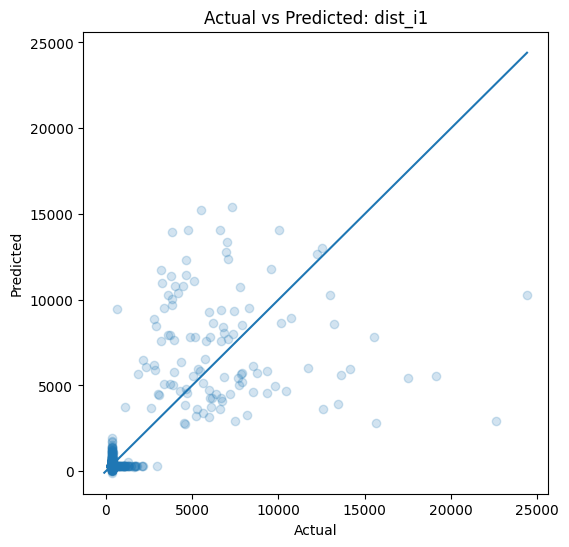

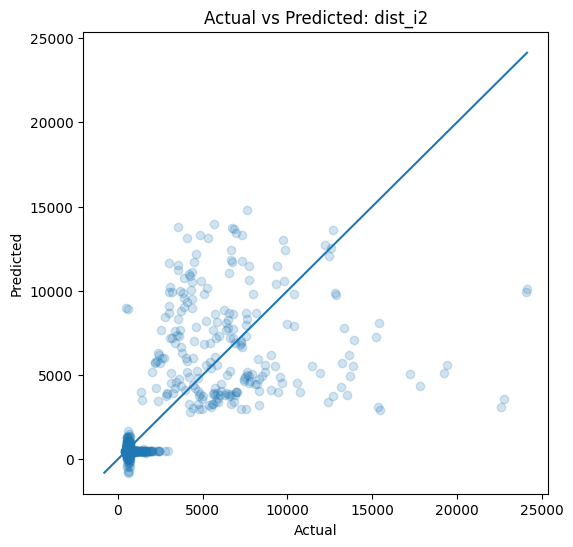

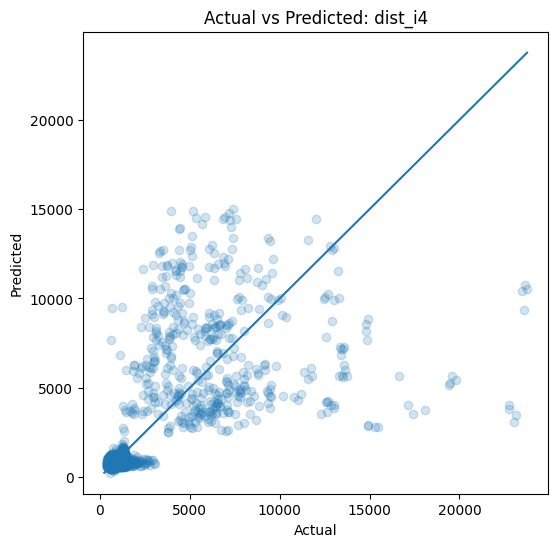

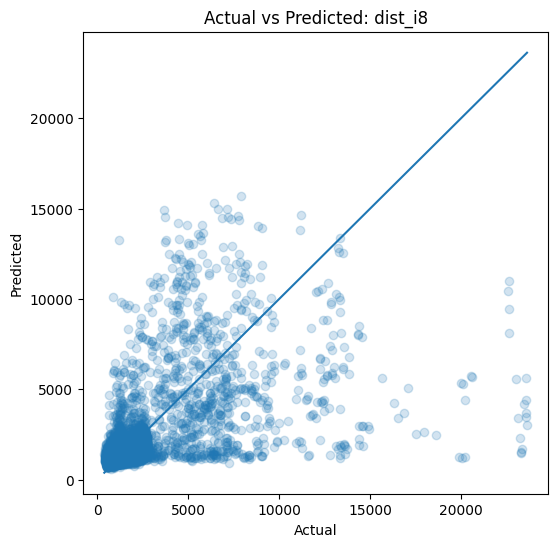

In [18]:
import matplotlib.pyplot as plt

target_names = ["dist_i1", "dist_i2", "dist_i4", "dist_i8"]

for i, name in enumerate(target_names):
    plt.figure(figsize=(6, 6))
    plt.scatter(targets[:, i], preds[:, i], alpha=0.2)
    min_val = min(targets[:, i].min(), preds[:, i].min())
    max_val = max(targets[:, i].max(), preds[:, i].max())
    plt.plot([min_val, max_val], [min_val, max_val])
    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.title(f"Actual vs Predicted: {name}")
    plt.show()

Residual Plot

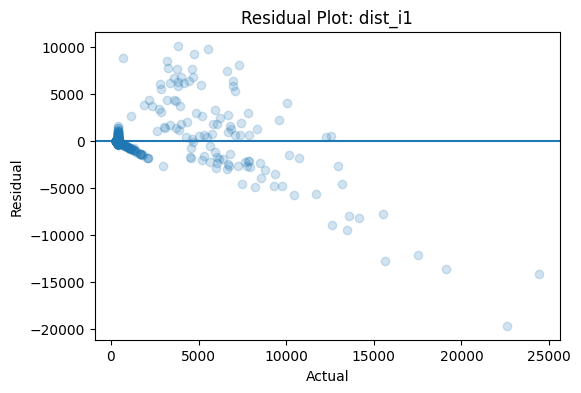

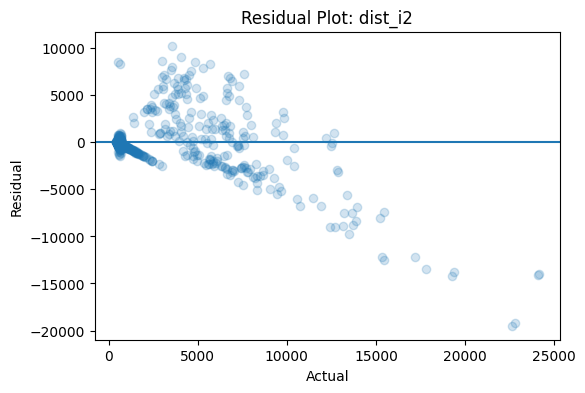

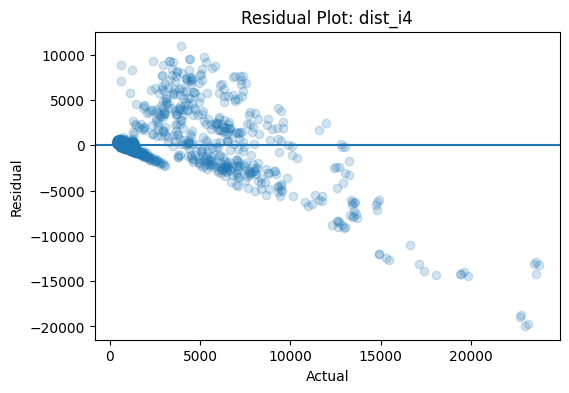

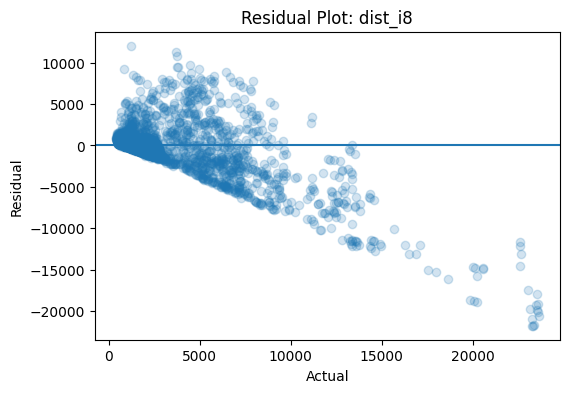

In [19]:
for i, name in enumerate(target_names):
    residuals = preds[:, i] - targets[:, i]

    plt.figure(figsize=(6, 4))
    plt.scatter(targets[:, i], residuals, alpha=0.2)
    plt.axhline(0)
    plt.xlabel("Actual")
    plt.ylabel("Residual")
    plt.title(f"Residual Plot: {name}")
    plt.show()

Plot per target R2

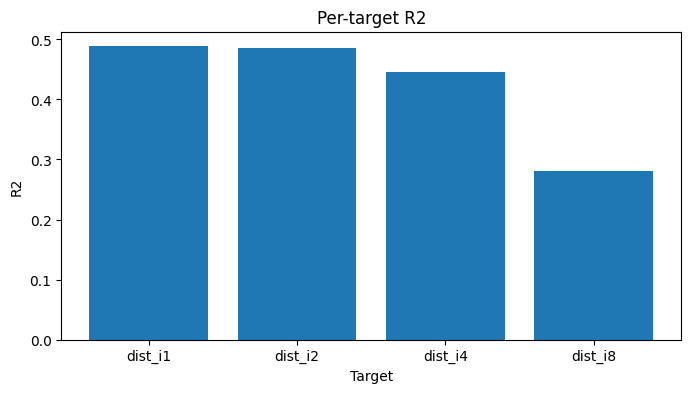

In [20]:

plt.figure(figsize=(8, 4))
plt.bar(per_target_df["Target"], per_target_df["R2"])
plt.xlabel("Target")
plt.ylabel("R2")
plt.title("Per-target R2")
plt.show()